In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

import medmnist
from medmnist import INFO


## Extracting the data from the dataset
Loads MedMNIST data into variables

In [39]:
dataset = "breastmnist"

info = INFO[dataset]
task = info["task"]
n_channels = info['n_channels']
n_classes = len(info['label'])

# Load training and test data using the local folder
DataClass = getattr(medmnist, info["python_class"])
train_dataset = DataClass(split="train", download=False)
val_dataset = DataClass(split="val", download=False)
test_dataset = DataClass(split="test", download=False)

Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 546
    Root location: C:\Users\Alvin\.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0


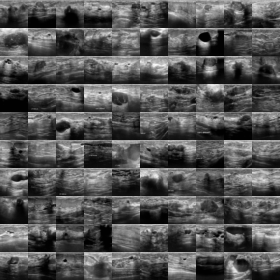

In [40]:
print(train_dataset)
train_dataset.montage(10)

## Using only flattened Image for input into SVM


In [41]:
train_images = np.array(train_dataset.imgs)
train_images_flat = np.array([train_images[i,:].flatten() for i in range(train_images.shape[0])])

val_images = np.array(val_dataset.imgs)
val_images_flat = np.array([val_images[i,:].flatten() for i in range(val_images.shape[0])])

test_images = np.array(test_dataset.imgs)
test_images_flat = np.array([test_images[i,:].flatten() for i in range(test_images.shape[0])])

train_labels = np.array(train_dataset.labels).flatten()
val_labels = np.array(val_dataset.labels).flatten()
test_labels = np.array(test_dataset.labels).flatten()

In [42]:
clf = svm.SVC()
clf.fit(train_images_flat, train_labels)

val_accuracy = clf.score(val_images_flat, val_labels)
print(val_accuracy)

0.8205128205128205


0.7948717948717948


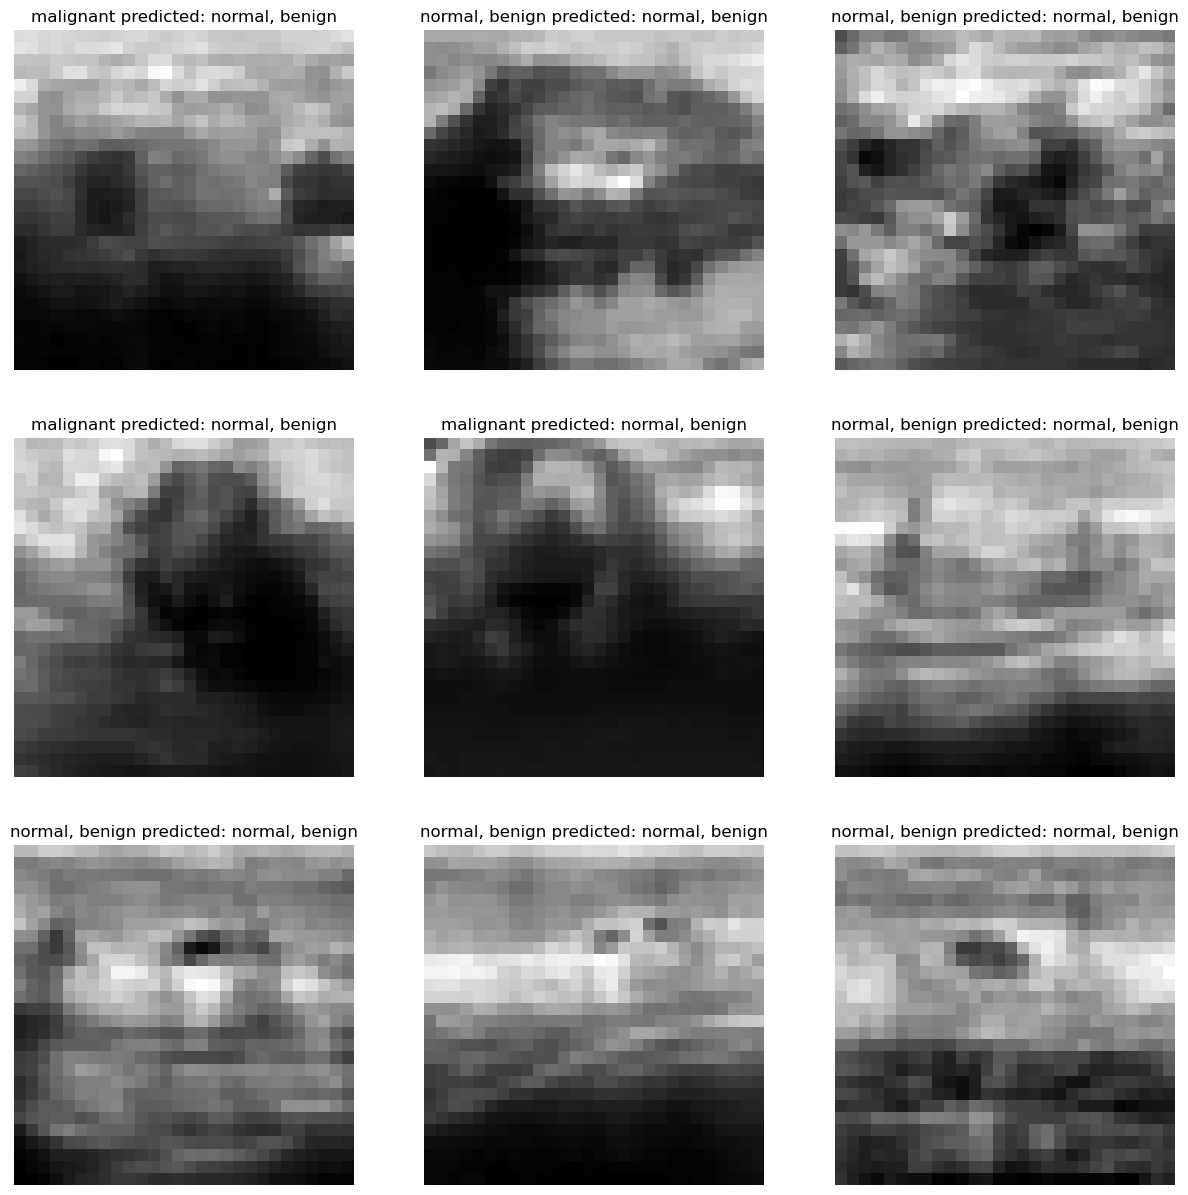

In [43]:
import random 

labels_map = {
    0: "malignant",
    1: "normal, benign"
}

figure = plt.figure(figsize=(15, 15))

for i in range(1, 9 + 1):
    sample_id = random.randint(0, test_images.shape[0])
    image = test_images[sample_id]
    label = test_labels[sample_id]
    flat_image = test_images_flat[sample_id].reshape(1,-1)
    prediction = clf.predict(flat_image).item()

    figure.add_subplot(3, 3, i)
    plt.title(f"{labels_map[label]} predicted: {labels_map[prediction]}")
    plt.axis("off")
    plt.imshow(image.squeeze(), cmap="gray")

plt.show

test_accuracy = clf.score(test_images_flat, test_labels)
print(test_accuracy)

## Now with feature extraction

While the accuracy is quite good, the large dimensionality of the dataset means the computation required is quite high.

Different methods of feature extraction is explored

In [50]:
from skimage.feature import hog


def extract_hog_feats(images):
    features = []

    for image in images:
        fd = hog(
            image,
            orientations=8,
            pixels_per_cell=(4, 4),
            cells_per_block=(1, 1),
            visualize=False,
            channel_axis=None,
        )

        features.append(fd)

    features = np.array(features)

    return features

train_features = extract_hog_feats(train_images)

feat_clf = svm.SVC()
feat_clf.fit(train_features, train_labels)

val_features = extract_hog_feats(val_images)
feat_val_accuracy = feat_clf.score(val_features, val_labels)
print(feat_val_accuracy)
 

0.8205128205128205


0.7948717948717948


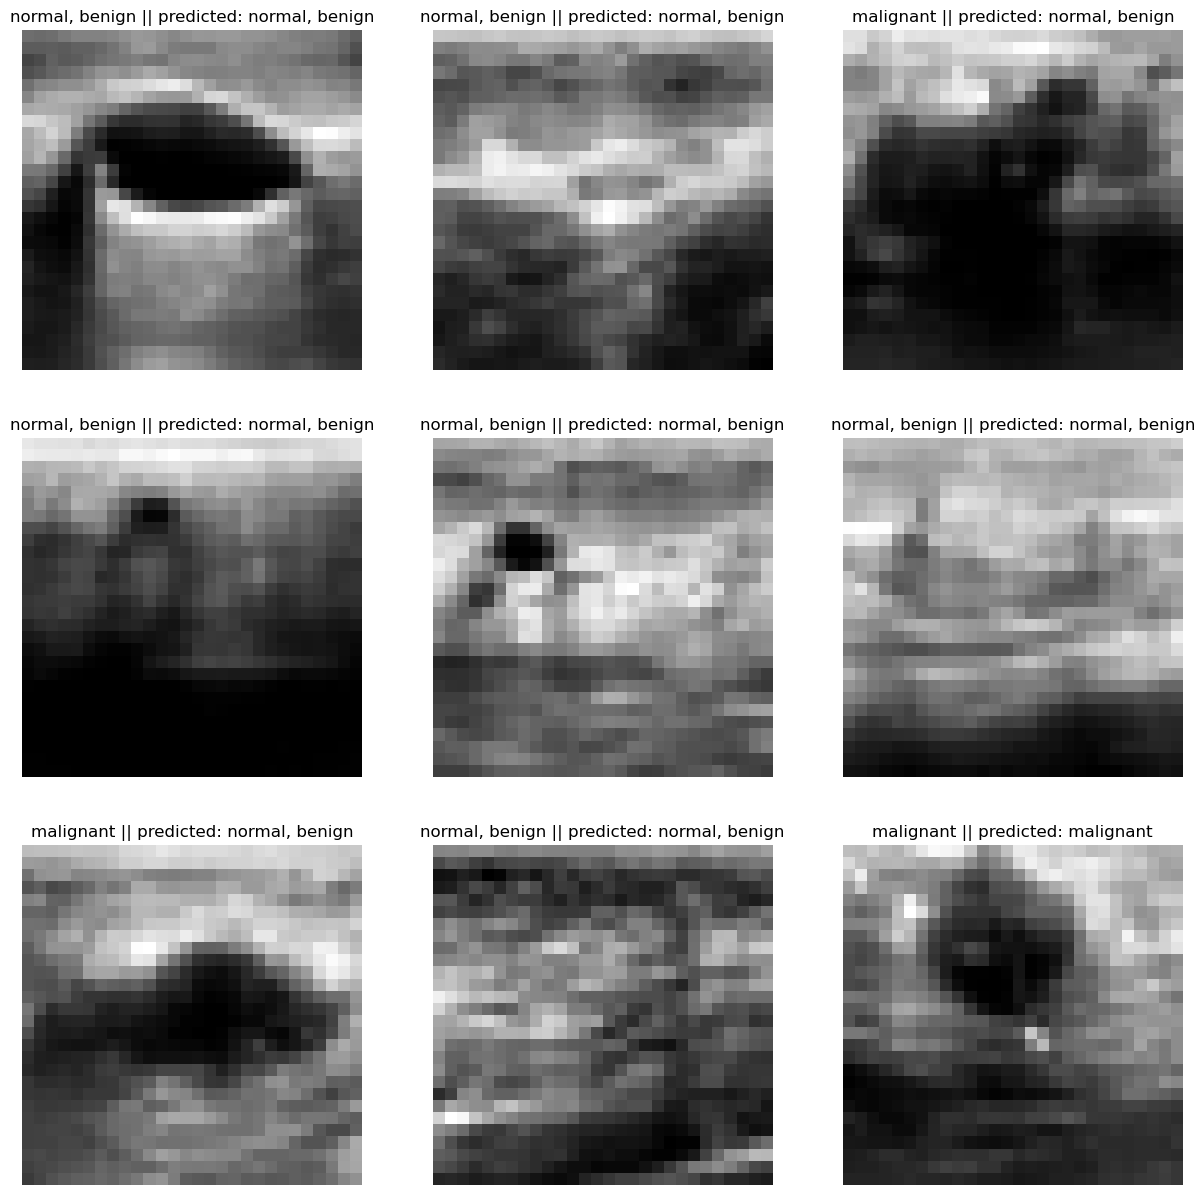

In [51]:
figure2 = plt.figure(figsize=(15, 15))

for i in range(1, 9 + 1):
    sample_id = random.randint(0, test_images.shape[0])
    image = test_images[sample_id]
    label = test_labels[sample_id]
    
    fd= hog(
            image,
            orientations=8,
            pixels_per_cell=(4, 4),
            cells_per_block=(1, 1),
            visualize=False,
            channel_axis=None,
        )

    prediction = feat_clf.predict(fd.reshape(1, -1)).item()

    figure2.add_subplot(3, 3, i)
    plt.title(f"{labels_map[label]} || predicted: {labels_map[prediction]}")
    plt.axis("off")
    plt.imshow(image.squeeze(), cmap="gray")

plt.show

test_accuracy = clf.score(test_images_flat, test_labels)
print(test_accuracy)